# Phase 2: SAE Cofiring Analysis

**2A — Cross-model cofiring**: Do NTP and STP SAE features correspond to the same concepts, grounded in which tokens they fire on?

**2B — Within-model cofiring graphs**: Does STP reorganize how features co-activate with each other?

Data: `synth_test.jsonl` (in-distribution, chat-templated, padding-filtered).

In [7]:
from phase2_cofiring import (
    load_chat_texts,
    collect_sae_activations,
    cross_model_cofiring,
    cofiring_summary,
    plot_cofiring_histogram,
    plot_mapping_cardinality,
    within_model_cofiring_stats,
    plot_degree_distribution,
    print_cofiring_comparison,
    investigate_spike,
)
from sae_analysis import load_hooked_model, load_sae
from transformers import AutoTokenizer

MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
SAE_PATHS = {
    "NTP": "/home/jay/repos/llm-jepa/trained_saes/ntp_layer15",
    "STP": "/home/jay/repos/llm-jepa/trained_saes/stp_layer15",
}
HOOK_NAME = "blocks.15.hook_resid_post"
SEQ_LEN = 128
BATCH_SIZE = 8


## Load Data and SAEs

In [2]:
synth_texts, _ = load_chat_texts("../datasets/synth_test.jsonl")
print(f"Synth test: {len(synth_texts)} examples")

saes = {label: load_sae(path) for label, path in SAE_PATHS.items()}
print(f"SAEs loaded: {list(saes.keys())}")

Synth test: 2000 examples
SAEs loaded: ['NTP', 'STP']


/home/jay/miniconda3/envs/jepa/lib/python3.14/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


## Collect SAE Activations

Run both models on the same synth_test tokens. Store binary activation matrices
(which features fired at each token). Load one model at a time to save VRAM.

In [3]:
import torch

sae_acts = {}
for label, model_path in MODELS.items():
    print(f"\nCollecting activations for {label}...")
    model = load_hooked_model(model_path)
    acts, n_tokens = collect_sae_activations(
        model, saes[label], synth_texts,
        hook_name=HOOK_NAME, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
    )
    sae_acts[label] = acts
    del model
    torch.cuda.empty_cache()
    print(f"  {n_tokens:,} real tokens, activation matrix: {acts.shape}")


Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  142,247 real tokens, activation matrix: (142247, 16384)

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  142,247 real tokens, activation matrix: (142247, 16384)


## 2A: Cross-Model Cofiring

Jaccard similarity between NTP and STP features, grounded in which tokens they
fire on. High Jaccard = same concept detected regardless of SAE basis choice.

In [4]:
print("Computing cross-model cofiring...")
cofiring_result = cross_model_cofiring(
    sae_acts["NTP"], sae_acts["STP"], min_fires=10
)
cofiring_summary(cofiring_result)

Computing cross-model cofiring...
  Live features (>=10 fires): A=503, B=553
  Computing co-occurrence matrix...
Cross-model cofiring: NTP → STP
  Tokens: 142,247
  Live features: NTP=503, STP=553

  NTP→STP:
    median max Jaccard: 0.3978
    mean max Jaccard:   0.4469
    fraction >= 0.1: 0.825
    fraction >= 0.3: 0.592
    fraction >= 0.5: 0.378

  STP→NTP:
    median max Jaccard: 0.3831
    mean max Jaccard:   0.4437
    fraction >= 0.1: 0.810
    fraction >= 0.3: 0.580
    fraction >= 0.5: 0.374



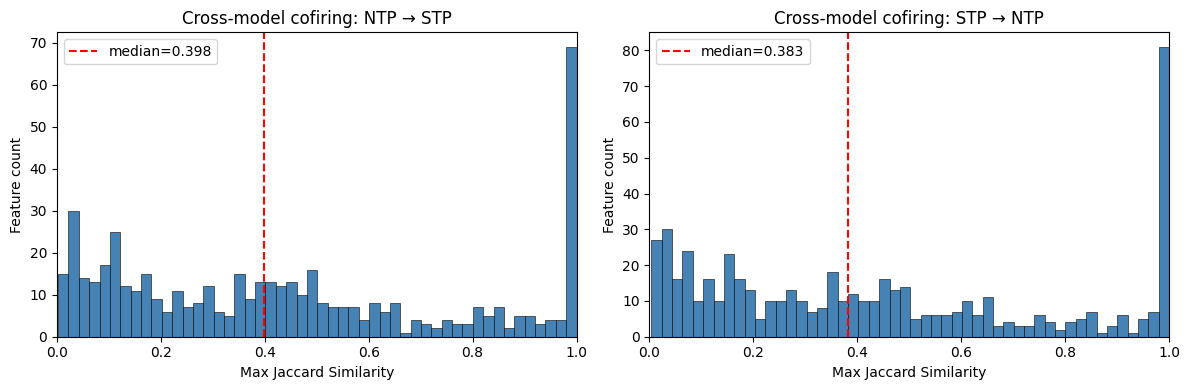

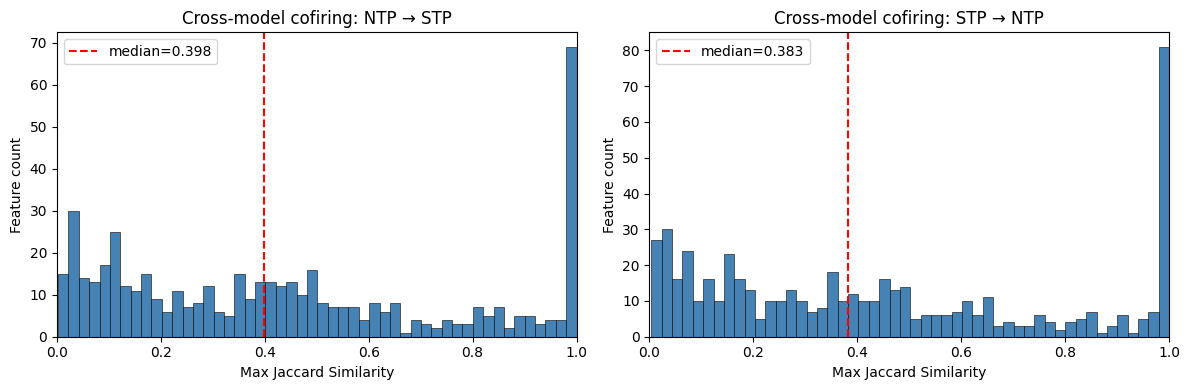

In [5]:
plot_cofiring_histogram(cofiring_result, save_path="phase2_cofiring_histogram.png")

interpretation: pretty low jaccard similarity between the sets. This means that either STP has dramatically changed the representations, or we just have a different SAE decomposition.

In [8]:
# What are the spike features? High fire count = system prompt?
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
tokenizer.pad_token = tokenizer.eos_token
spike_info = investigate_spike(
    cofiring_result, sae_acts["NTP"], sae_acts["STP"],
    synth_texts, tokenizer,
    spike_thresh=0.95, seq_len=SEQ_LEN,
)


Spike features (Jaccard >= 0.95): 76 of 503 live NTP features

Fire counts — spike features:     median=2000, mean=2005
Fire counts — non-spike features: median=759, mean=2824

Top 10 spike features (by Jaccard):
  feat   805  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat   881  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  1362  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  1416  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  1471  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  1519  jaccard=1.000  fires= 2408  top tokens: 'lines'×2000, ' words'×408
  feat  1573  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  1897  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  2226  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×2000
  feat  2259  jaccard=1.000  fires= 2000  top tokens: '<|begin_of_text|>'×

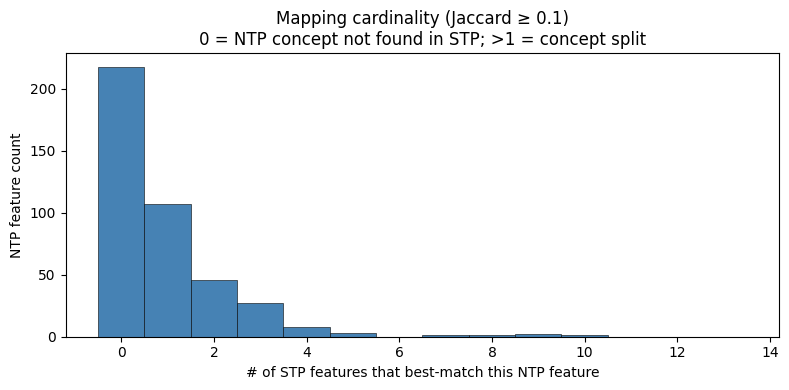

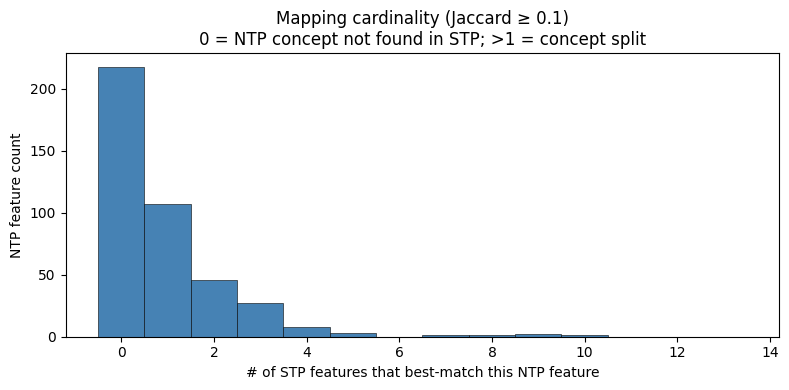

In [ ]:
# Cardinality: are NTP concepts split into multiple STP features, or merged?
plot_mapping_cardinality(
    cofiring_result, jaccard_thresh=0.1,
    save_path="phase2_cardibtweenality.png"
)

## 2B: Within-Model Cofiring Graphs

For each SAE independently: how densely connected is the feature co-activation graph?
Compare degree distributions and clustering coefficients between NTP and STP.

In [8]:
graph_stats = {}
for label in ["NTP", "STP"]:
    print(f"\n{label} within-model cofiring:")
    graph_stats[label] = within_model_cofiring_stats(
        sae_acts[label], jaccard_thresh=0.05, min_fires=10
    )


NTP within-model cofiring:
  Live features: 503 (of 16384)
  Computing within-model co-occurrence...
  Mean degree: 25.8, Median: 14.0
  Mean clustering coefficient (sample n=500): 0.5641

STP within-model cofiring:
  Live features: 553 (of 16384)
  Computing within-model co-occurrence...
  Mean degree: 30.0, Median: 16.0
  Mean clustering coefficient (sample n=500): 0.5684


In [9]:
print_cofiring_comparison(graph_stats["NTP"], graph_stats["STP"])

Within-model cofiring graph statistics:
Metric                                      NTP         STP        Diff
----------------------------------------------------------------------
  Live features                             503         553         +50
  Mean degree                             25.81       30.01       +4.20
  Median degree                           14.00       16.00       +2.00
  Clustering coefficient                 0.5641      0.5684     +0.0043


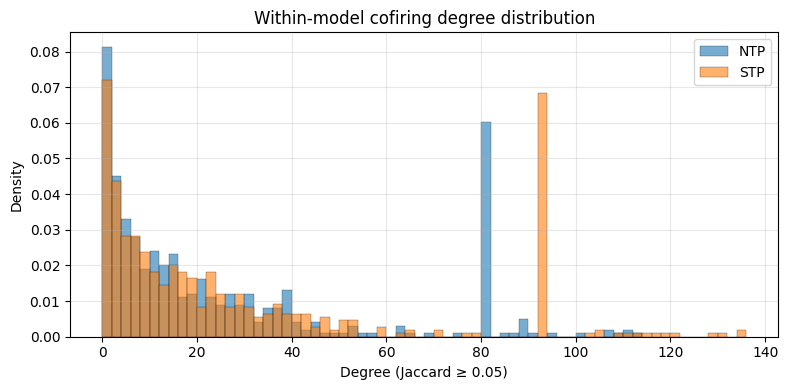

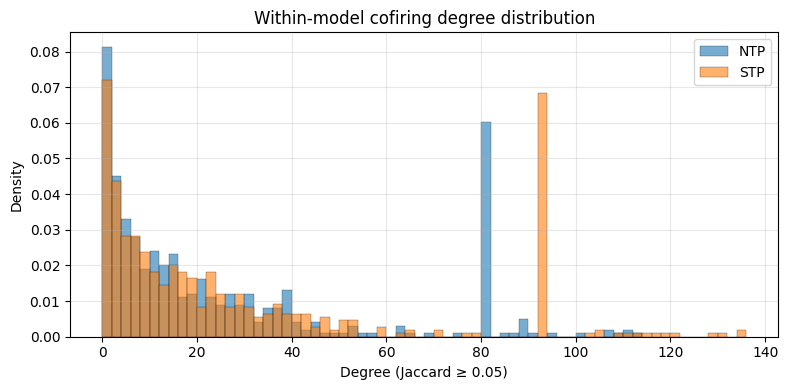

In [10]:
plot_degree_distribution(graph_stats, save_path="phase2_degree_distribution.png")

interpretation: co-activation with each model is about the same: each live feature tends to fire together with about 25-30 other features on the same tokens. This would indicate density hasn't changed. The spikes are probably just system tokens.